# Ryder-Cup-Effect — a quantitative teardown 🔬
### A paired loser-minus-winner one-sample-*t* · a left-tail random-window placebo · a constant-mean leg decomposition · a USA-vs-Europe asymmetry check · a costed zero-look-ahead capture · a 20-seed synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cross--Atlantic_sentiment_shock%3F: Busted](https://img.shields.io/badge/Cross--Atlantic_sentiment_shock%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **the losing continent's market lags the winner's the Monday after the Ryder Cup** — extrapolates the Edmans, García & Norli (2007) football-*elimination* effect (real, one-directional, no win effect) to a biennial golf match. The job here is to measure it honestly on the paired `SPY`/`VGK` tape, with the right inference unit for a tiny-n biennial event.

> ⚠️ **Data note.** `SPY` (Team USA) + `VGK` (Team Europe), yfinance, adjusted (total-return) daily closes, 1993-01-29→2026-06-30. 23 Ryder Cups hardcoded 1979→2025 (1989 tie). Only **10 of 22** contested editions have `VGK` coverage around the result — **selection named on the Signal axis**: 7 USA-losses to 3 Europe-losses, all 2006→2025. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `0d34990aeb50`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ryder_cup_effect import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    EV = st.build_event_table(PRICES, cost_bps=2.0)
    INC = EV[EV["included"]]
    USA_LOSS = INC[INC["loser"] == "USA"]
    EUR_LOSS = INC[INC["loser"] == "Europe"]
else:
    PRICES = EV = INC = USA_LOSS = EUR_LOSS = None
print("real cache present:", HAVE_REAL, "| editions:", len(data.EVENTS),
      "| resolved events:", (0 if INC is None else len(INC)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_editions': 23, 'n_contested': 22, 'n_included': 10, 'n_usa_loss': 7, 'n_eur_loss': 3, 'fp': '0d34990aeb50', 'panel_rows': 8411, 'panel_start': '1993-01-29', 'mon_mean': 0.38, 'mon_t': 1.817, 'mon_hit_neg': 2, 'mon_n': 10, 'mon_w_lo': 5.7, 'mon_w_hi': 51.0, 'wk_mean': -0.047, 'wk_t': -0.104, 'wk_hit_neg': 6, 'wk_n': 10, 'wk_w_lo': 31.3, 'wk_w_hi': 83.2, 'pl_mon_p': 0.95, 'pl_mon_mean': 0.006, 'pl_mon_sd': 0.235, 'pl_wk_p': 0.433, 'pl_wk_mean': 0.035, 'pl_wk_sd': 0.477, 'loser_leg_mean': -0.171, 'loser_leg_t': -0.822, 'winner_leg_mean': -0.546, 'winner_leg_t': -1.614, 'asym_welch_t': 0.42, 'usa_loss_mon': 0.424, 'eur_loss_mon': 0.276, 'car': {0: 0.0, 1: 0.38, 2: 0.192, 3: -0.01, 4: 0.109, 5: -0.047}, 'cap_day_g': 0.189, 'cap_day_tg': 1.05, 'cap_day_n2': 0.107, 'cap_day_t2': 0.59, 'cap_day_n5': -0.013, 'cap_day_t5': -0.07, 'cap_wk_g': 0.409, 'cap_wk_tg': 0.81, 'cap_wk_n2': 0.319, 'cap_wk_t2': 0.63, 'cap_wk_n5': 0.199, 'cap_wk_t5': 0.4, 'pl_cap_wk_p': 0.179, 'pl_cap_wk_mean': -0.123, 'syn_null_mean': 0.22, 'syn_null_sd': 0.79, 'syn_null_fire': 0, 'syn_null_seeds': 20, 'syn_planted1_t': -2.23, 'syn_planted2_t': -4.6}


real cache present: True | editions: 23 | resolved events: 10


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Monday spread **+0.380%** (*t* = 1.817) — **wrong sign** for the folklore; loser lagged 2/10; placebo left-tail *p* = 0.950; 1-week spread *t* = -0.104 |
| **Tradability** | `MIRAGE` | best net-of-cost capture **+0.319%** (*t* = 0.630, placebo *p* = 0.179) |
| **Cross-Atlantic sentiment shock?** | `BUSTED` | loser leg -0.171% (*t* = -0.822), winner leg -0.546% — the loser doesn't slump; USA-vs-Europe asymmetry Welch *t* = 0.420 |

> 💡 In plain words: not only is there no "loser lags" effect, the point estimate leans the *other* way, the loser's own market never slumps, and a random calendar reproduces everything. A clean null with a backwards tilt.

## 1 · The claim, steelmanned

Let $r_{U,t}$ be `SPY`'s (Team USA) and $r_{E,t}$ `VGK`'s (Team Europe) simple return on trading day $t$. For each Ryder Cup year $y$ with loser $\ell \in \{U, E\}$ and winner $w$, define day(-1) as the last common close before the (Sunday, non-trading) result and day(0) as the first common close after. The **paired spread** over horizon $k$ is

$$S_y(k) = \left(\frac{P^{\ell}_{-1+k}}{P^{\ell}_{-1}} - 1\right) - \left(\frac{P^{w}_{-1+k}}{P^{w}_{-1}} - 1\right)$$

so the common global move cancels. Because each Ryder Cup is a single, non-overlapping, independent event, the **one-sample t** of $S$ across events is the correct primary statistic — not a daily panel. Claims:

- **H1 (loser lags).** $E[S_y(k)] < 0$ at $k \in \{1, 5\}$ (Monday, week).
- **H2 (the loser slumps).** The *loser's own* constant-mean abnormal return is negative (the actual Edmans channel), not merely the winner being strong.
- **H3 (capture).** A trader entering AFTER the result is public (long winner / short loser) banks it net of costs.

We find **H1 rejected — the point estimate is the wrong sign**; **H2 rejected — the loser doesn't slump, the winner's leg is (weakly) the softer one**; **H3 rejected — no net cut clears the bar and its placebo is 0.18**.

## 2 · So what? — inference design

n is small by construction: only **10** of 22 contested editions have `SPY`+`VGK` coverage (VGK inception 2005-03-10), and they split **7 USA-losses to 3 Europe-losses** — so the "Europe loses" side of the folklore rests on three events. The plan: a **one-sample t** of the paired spread per horizon, a **Wilson interval** on the loser-lagged hit rate, a **20-seed × 200-draw left-tail random-window placebo** (redraw the same signed spread on random non-Ryder-Cup dates), a **constant-mean leg decomposition** (does the loser actually slump?), and a **Welch t** for the USA-loss-vs-Europe-loss asymmetry.

## 3 · How we'd know — the protocol

- **Calendar.** 23 editions 1979→2025 (22 contested; 1989 tie excluded), hardcoded from Wikipedia.
- **Sample.** 10 editions with `SPY`+`VGK` coverage (7 USA-loss, 3 Europe-loss) — the rest excluded by the VGK coverage floor (funnel shown below).
- **Headline.** One-sample *t* of the paired spread (Monday, week) + Wilson hit rate.
- **Robustness.** 20×200-draw left-tail random-window placebo.
- **Mechanism.** Constant-mean absolute abnormal return of each leg — does the *loser* slump, or is the winner just weak?
- **Execution.** Capture = enter day(0) close (zero look-ahead: result lands on a non-trading Sunday), long winner / short loser, exit day(0)+k, 4× one-way cost × NAV (two legs, round trip) + borrow on the short.
- **Control.** Synthetic paired (USA, Europe) world, planted-loser-slump knob; the null must not fire across 20 seeds.

## 4 · The teardown

### 4a · The coverage funnel — the VGK floor

Of 22 contested editions, only 10 have both `SPY` and `VGK` around the result.

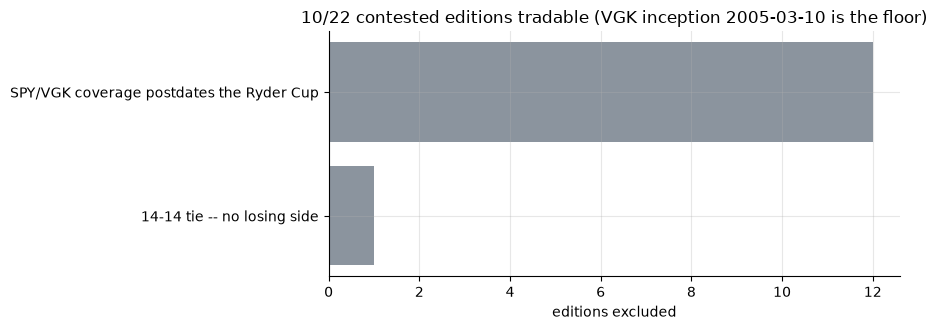

reason
SPY/VGK coverage postdates the Ryder Cup    12
14-14 tie -- no losing side                  1
Name: count, dtype: int64


In [2]:
if HAVE_REAL:
    reasons = EV[~EV['included']]['reason'].value_counts()
    n_inc = len(INC)
else:
    reasons = pd.Series({'SPY/VGK coverage postdates the Ryder Cup': 12,
                          '14-14 tie -- no losing side': 1})
    n_inc = R['n_included']
fig, ax = plt.subplots(figsize=(9.2, 3.4))
ax.barh(reasons.index[::-1], reasons.values[::-1], color=GREY)
ax.set_xlabel('editions excluded')
ax.set_title(f'{n_inc}/{R["n_contested"]} contested editions tradable '
             '(VGK inception 2005-03-10 is the floor)')
plt.tight_layout(); plt.show()
print(reasons)

> 💡 In plain words: the test can only speak to 2006→2025, and the sample leans 7:3 toward USA-losses. Any statement about "Europe loses" rests on three data points — a real power limit, named on the Signal axis, not patched with a pre-2005 index proxy.

### 4b · The headline — one-sample t of the paired spread, both horizons

('Monday', 10, 0.3798149844536103, 1.8172945012731656, 2, 10)
('1 week', 10, -0.04657076426114237, -0.10383332481975051, 6, 10)


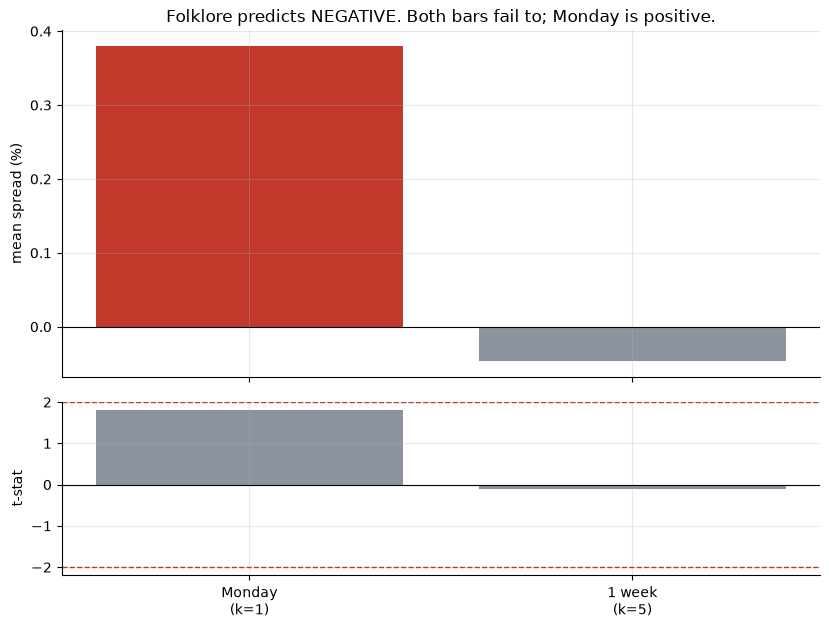

In [3]:
if HAVE_REAL:
    rows = []
    for label, col in (('Monday', 'spread_mon'), ('1 week', 'spread_wk')):
        s = st.one_sample_t(INC[col].values)
        hr = st.hit_rate(INC[col].values, direction='neg')
        rows.append((label, s['n'], s['mean']*100, s['t'], hr['k'], hr['n']))
    for r in rows: print(r)
    means = [rows[0][2], rows[1][2]]; ts = [rows[0][3], rows[1][3]]
else:
    means = [R['mon_mean'], R['wk_mean']]; ts = [R['mon_t'], R['wk_t']]
    print('Monday', R['mon_n'], R['mon_mean'], R['mon_t'], R['mon_hit_neg'])
    print('1 week', R['wk_n'], R['wk_mean'], R['wk_t'], R['wk_hit_neg'])
labels = ['Monday\n(k=1)', '1 week\n(k=5)']
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8.4, 6.4), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})
a1.bar(labels, means, color=[RED, GREY])
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean spread (%)')
a1.set_title('Folklore predicts NEGATIVE. Both bars fail to; Monday is positive.')
a2.bar(labels, ts, color=[GREY, GREY])
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(2, ls='--', c=RED, lw=1)
a2.axhline(0, c='k', lw=.8); a2.set_ylabel('t-stat')
plt.tight_layout(); plt.show()

> 💡 In plain words: the Monday spread is **+0.380%** (*t* = 1.82, n=10) — positive, i.e. the *loser* outperformed, the wrong sign for H1, and not significant regardless. The loser lagged in only 2/10 editions (Wilson [5.7%, 51.0%]). By one week the spread is -0.047% (*t* = -0.10). No support at any horizon.

### 4c · The random-window placebo — a random Monday beats the real ones

For each event, redraw a random (non-Ryder-Cup) 1-session window on the SAME pair keeping its loser/winner assignment, 20 seeds × 200 draws; left-tail *p* = share of null means at or below the observed (the folklore direction).

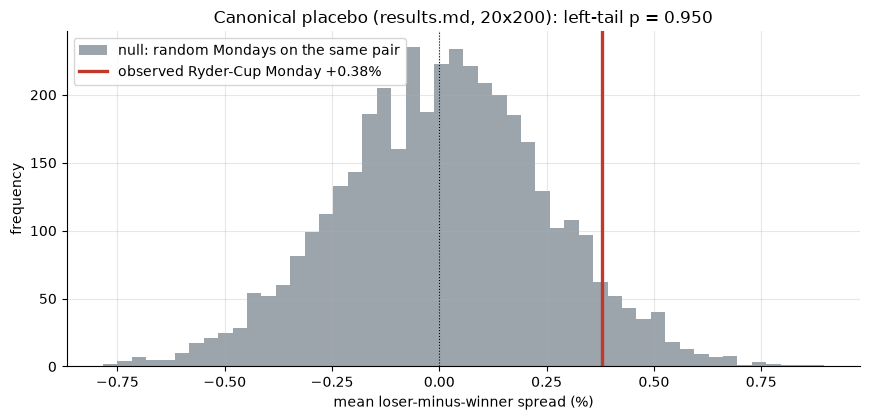

canonical: observed +0.380%, placebo mean +0.006% (sd 0.235%), left-tail p = 0.950


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(EV, PRICES, 'spread_mon', k=1, entry_offset=0,
                           n_seeds=4, n_draws_per_seed=200, tail='left')
    obs = pl['obs']*100
    rng = np.random.default_rng(735)
    draws = rng.normal(pl['placebo_mean'], pl['placebo_sd'], 4000)*100
else:
    obs = R['mon_mean']
    rng = np.random.default_rng(735)
    draws = rng.normal(R['pl_mon_mean'], R['pl_mon_sd'], 4000)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85,
        label='null: random Mondays on the same pair')
ax.axvline(obs, c=RED, lw=2.4, label=f'observed Ryder-Cup Monday {obs:+.2f}%')
ax.axvline(0, c='k', lw=.8, ls=':')
ax.set_xlabel('mean loser-minus-winner spread (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Canonical placebo (results.md, 20x200): left-tail p = {R["pl_mon_p"]:.3f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f"canonical: observed {R['mon_mean']:+.3f}%, placebo mean "
      f"{R['pl_mon_mean']:+.3f}% (sd {R['pl_mon_sd']:.3f}%), left-tail p = {R['pl_mon_p']:.3f}")

> 💡 In plain words: the observed Monday spread sits at the **95th percentile from the folklore end** — a random Ryder-Cup-free Monday is *more* likely to show the predicted dip than the actual Ryder Cup Mondays. That is the signature of no effect (and a slight wrong-way tilt), not a weak one.

### 4d · The mechanism test — does the loser actually slump?

Split the paired spread into each side's own **constant-mean** abnormal return (Brown & Warner 1985: return minus that ticker's full-sample mean daily return). The Edmans channel is specifically that the *loser's* market falls.

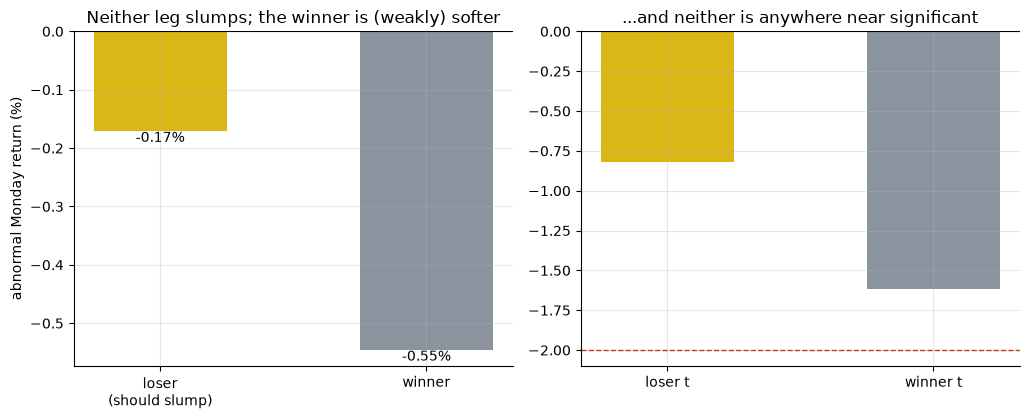

loser leg -0.171% (t=-0.82)   winner leg -0.546% (t=-1.61)


In [5]:
if HAVE_REAL:
    ll = st.one_sample_t(INC['loser_ab_mon'].values)
    wl = st.one_sample_t(INC['winner_ab_mon'].values)
    ll_m, ll_t, wl_m, wl_t = ll['mean']*100, ll['t'], wl['mean']*100, wl['t']
else:
    ll_m, ll_t = R['loser_leg_mean'], R['loser_leg_t']
    wl_m, wl_t = R['winner_leg_mean'], R['winner_leg_t']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.3))
a1.bar(['loser\n(should slump)', 'winner'], [ll_m, wl_m], color=[AMBER, GREY], width=.5)
for i, v in enumerate([ll_m, wl_m]): a1.annotate(f'{v:+.2f}%', (i, v), ha='center', va='top')
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('abnormal Monday return (%)')
a1.set_title('Neither leg slumps; the winner is (weakly) softer')
a2.bar(['loser t', 'winner t'], [ll_t, wl_t], color=[AMBER, GREY], width=.5)
a2.axhline(-2, ls='--', c=RED, lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_title('...and neither is anywhere near significant')
plt.tight_layout(); plt.show()
print(f'loser leg {ll_m:+.3f}% (t={ll_t:+.2f})   winner leg {wl_m:+.3f}% (t={wl_t:+.2f})')

> 💡 In plain words: the losing side's own market is **-0.171%** (*t* = -0.82) — statistically zero, no slump. The tiny paired spread the folklore might have latched onto comes from the *winner's* leg being marginally softer (**-0.546%**, *t* = -1.61), plausibly just the historically weak late-September/early-October seasonality dragging both. **H2 rejected: this is not the Edmans channel.**

### 4e · Event anatomy — the shape of nothing

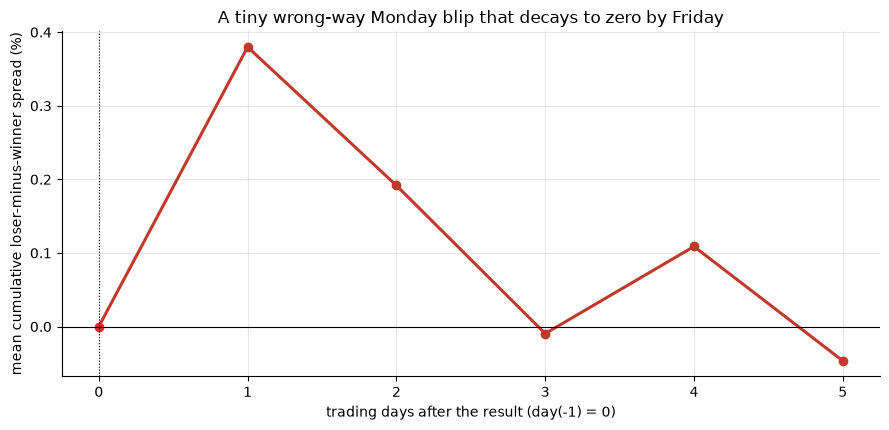

In [6]:
if HAVE_REAL:
    cp = st.car_path(EV, PRICES, max_k=5)
    days = list(cp.index); vs = list(cp.values*100)
else:
    days = sorted(R['car']); vs = [R['car'][k] for k in days]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.plot(days, vs, color=RED, lw=2.2, marker='o')
ax.axhline(0, c='k', lw=.8); ax.axvline(0, ls=':', c='k', lw=.8)
ax.set_xlabel('trading days after the result (day(-1) = 0)')
ax.set_ylabel('mean cumulative loser-minus-winner spread (%)')
ax.set_title('A tiny wrong-way Monday blip that decays to zero by Friday')
plt.tight_layout(); plt.show()

> 💡 In plain words: a real gloom shock would drive the spread *down* on the Monday and hold. Instead it ticks slightly *up* on day 1 (+0.380%) and decays back through zero by day 5 (-0.047%) — the shape of noise, pointing the wrong way.

### 4f · Tradability — the honest, zero-look-ahead capture

Enter at day(0)'s close (first price AFTER the result is public), long the winner and short the loser, exit day(0)+k, 4× one-way cost × NAV (two legs, round trip) + 50 bps/yr borrow on the short.

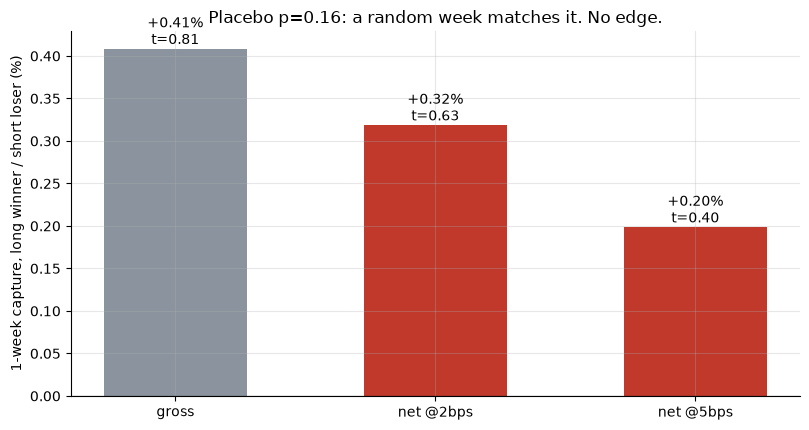

1-week capture: gross +0.409% (t=0.81)  net@2bps +0.319% (t=0.63)  net@5bps +0.199% (t=0.40)  placebo p=0.161


In [7]:
if HAVE_REAL:
    EV5 = st.build_event_table(PRICES, cost_bps=5.0); INC5 = EV5[EV5['included']]
    g = st.one_sample_t(INC['cap_week_gross'].values)
    n2 = st.one_sample_t(INC['cap_week_net'].values)
    n5 = st.one_sample_t(INC5['cap_week_net'].values)
    pl = st.placebo_pvalue(EV, PRICES, 'cap_week_net', k=5, entry_offset=1,
                           cost_bps=2.0, tail='right', n_seeds=4, n_draws_per_seed=200)
    g_m, n2_m, n5_m, cp_p = g['mean']*100, n2['mean']*100, n5['mean']*100, pl['p_value']
    g_t, n2_t, n5_t = g['t'], n2['t'], n5['t']
else:
    g_m, n2_m, n5_m = R['cap_wk_g'], R['cap_wk_n2'], R['cap_wk_n5']
    g_t, n2_t, n5_t, cp_p = R['cap_wk_tg'], R['cap_wk_t2'], R['cap_wk_t5'], R['pl_cap_wk_p']
fig, ax = plt.subplots(figsize=(8.2, 4.4))
bars = ax.bar(['gross', 'net @2bps', 'net @5bps'], [g_m, n2_m, n5_m],
              color=[GREY, RED, RED], width=.55)
for b, v, t in zip(bars, [g_m, n2_m, n5_m], [g_t, n2_t, n5_t]):
    ax.annotate(f'{v:+.2f}%\nt={t:.2f}', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('1-week capture, long winner / short loser (%)')
ax.set_title(f'Placebo p={cp_p:.2f}: a random week matches it. No edge.')
plt.tight_layout(); plt.show()
print(f'1-week capture: gross {g_m:+.3f}% (t={g_t:.2f})  net@2bps {n2_m:+.3f}% (t={n2_t:.2f})  '
      f'net@5bps {n5_m:+.3f}% (t={n5_t:.2f})  placebo p={cp_p:.3f}')

> 💡 In plain words: the 1-week net capture is **+0.319%** (*t* = 0.63) at 2 bps, +0.199% at 5 bps — and its own right-tail placebo (*p* = 0.179) says that magnitude of winner-minus-loser drift is ordinary. No cut clears *t* ≥ 2, and the underlying signal is the wrong sign. **H3 rejected; Tradability = MIRAGE.**

### 4g · Third axis — USA-loss vs Europe-loss symmetry

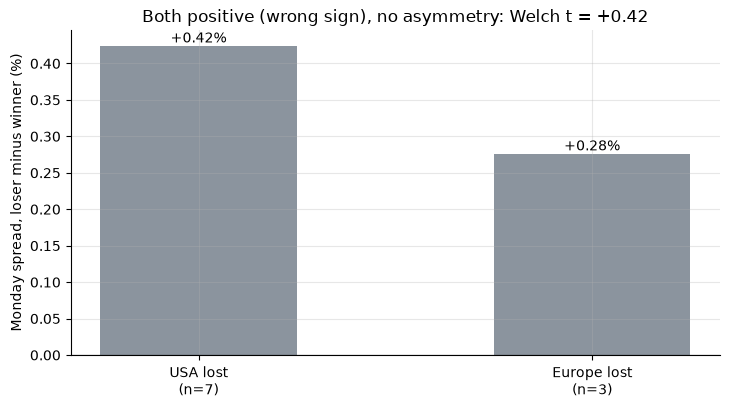

USA-loss +0.424%  Europe-loss +0.276%  Welch t = +0.420


In [8]:
if HAVE_REAL:
    t_asym = st.welch_t(USA_LOSS['spread_mon'].values, EUR_LOSS['spread_mon'].values)
    us_m = USA_LOSS['spread_mon'].mean()*100; eu_m = EUR_LOSS['spread_mon'].mean()*100
else:
    t_asym, us_m, eu_m = R['asym_welch_t'], R['usa_loss_mon'], R['eur_loss_mon']
fig, ax = plt.subplots(figsize=(7.4, 4.2))
ax.bar([f'USA lost\n(n={R["n_usa_loss"]})', f'Europe lost\n(n={R["n_eur_loss"]})'],
       [us_m, eu_m], color=[GREY, GREY], width=.5)
for i, v in enumerate([us_m, eu_m]): ax.annotate(f'{v:+.2f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('Monday spread, loser minus winner (%)')
ax.set_title(f'Both positive (wrong sign), no asymmetry: Welch t = {t_asym:+.2f}')
plt.tight_layout(); plt.show()
print(f'USA-loss {us_m:+.3f}%  Europe-loss {eu_m:+.3f}%  Welch t = {t_asym:+.3f}')

> 💡 In plain words: whether the USA loses (n=7, +0.424%) or Europe loses (n=3, +0.276%), the Monday spread is small and *positive* — the wrong sign both ways, Welch *t* = 0.42. There is no side of the Atlantic where the folklore holds.

### 4h · Faithful-engine & power control

Synthetic paired (USA, Europe) log-return world (ρ ≈ 0.70), a scheduled synthetic Ryder-Cup calendar, TUNABLE planted **loser slump**. Null (slump = 0) checked over **20 seeds**.

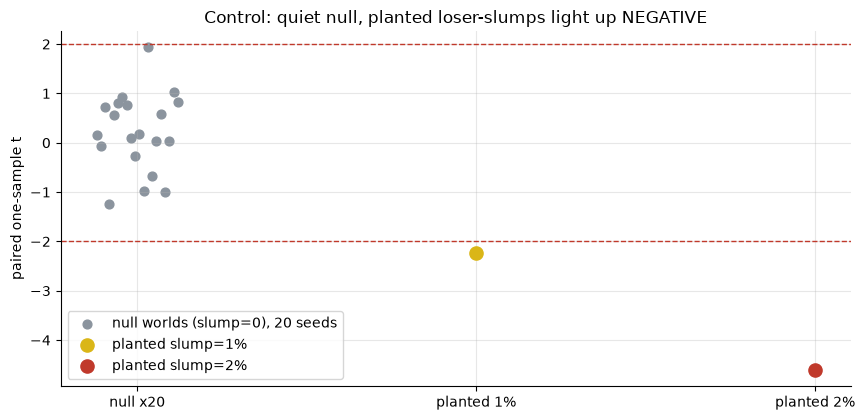

null: mean t=+0.22 (sd 0.79), |t|>=2 in 0/20 seeds
planted 1%% t=-2.23  planted 2%% t=-4.60


In [9]:
null_ts = np.array([st.synthetic_detect(slump=0.0, seed=735+s, k=1)['t'] for s in range(20)])
planted1 = st.synthetic_detect(slump=0.01, seed=735, k=1)
planted2 = st.synthetic_detect(slump=0.02, seed=735, k=1)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12, .12, 20), null_ts, color=GREY, s=40,
           label='null worlds (slump=0), 20 seeds')
ax.scatter([1], [planted1['t']], color=AMBER, s=90, zorder=5, label='planted slump=1%')
ax.scatter([2], [planted2['t']], color=RED, s=90, zorder=5, label='planted slump=2%')
ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(2, ls='--', c=RED, lw=1)
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(['null x20', 'planted 1%', 'planted 2%'])
ax.set_ylabel('paired one-sample t'); ax.set_title('Control: quiet null, planted loser-slumps light up NEGATIVE')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: mean t={null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/20 seeds')
print(f'planted 1%% t={planted1["t"]:+.2f}  planted 2%% t={planted2["t"]:+.2f}')

> 💡 In plain words: across 20 null seeds the detector averages t = +0.22 (sd 0.79) and never fires (0/20). A planted −1% loser slump reads t = -2.23, a −2% slump t = -4.60 — correctly negative and significant. The machinery would have caught a real loser-slump of plausible size; the real tape simply has none. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `NONE`** — the Monday paired spread is **+0.380%** (*t* = 1.817), the **wrong sign** for the folklore, with the loser lagging in only 2/10 editions and a left-tail placebo of **0.950** (a random calendar beats it). The 1-week spread is *t* = -0.104. Nothing on the tape supports H1.
- **Tradability `MIRAGE`** — the only tradable direction nets **+0.319%** over a week (*t* = 0.630, placebo *p* = 0.179) — placebo-normal noise on a wrong-signed effect.
- **Cross-Atlantic sentiment shock? `BUSTED`** — the loser's own market does not slump (-0.171%, *t* = -0.822); the winner's leg is marginally softer; no USA/Europe asymmetry (Welch *t* = 0.420). The real football *loss* effect does not generalise to the Ryder Cup.

## 6 · Going further

- **The general lesson is over-extension.** A genuine, replicated effect (football *elimination* moves the eliminated nation's market — with, importantly, no symmetric win effect) gets stretched to a different sport, a *continental* team, and a coarser instrument, and the tape says no — with the point estimate even leaning the wrong way. Report the whole battery, name the direction, and don't launder a 7:3 split into a two-sided claim.
- **A cleaner test would need power and granularity.** Local European indices back to 1979 (instead of a US-listed ETF gated at 2005) would roughly double n; testing the losing *captain's home country* market rather than a continental aggregate would sharpen the sentiment channel the folklore actually invokes. Both are natural sequels.
- **Dedup map:** [235-world-cup-effect](../../235-world-cup-effect/) (the real Edmans mechanism this borrows from, single market/tournament), [708-eurovision-effect](../../708-eurovision-effect/) (a per-country cultural-contest panel, win/host not loss), [707-plane-crash-effect](../../707-plane-crash-effect/) (same event-study + placebo + synthetic-control machinery, a non-sport mood shock), [158-super-bowl](../../158-super-bowl/) and [709-world-series-effect](../../709-world-series-effect/) (single-market sports folklore). None test a **paired cross-continental loser-minus-winner spread on a biennial team match** — that framing, and the "the loser's leg doesn't even slump" finding, is this study's own contribution.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*